# Objectives

In this notebook, the results of CKF stress test using KITTI dataset is agregated and the agregated results are exported.
The noise stress test is conducted on CKF with variable noise factor in range 0.1, 1.0, and 10.0 for sensor modality including OXTS IMU, OXTS GPS and Visual Odometry. Hence, there are 27 combinations of sensor configuration

The data agregation includes:
- 2D heat map per sensor axis (e.g., 3x3 heatmap for each IMU configuration: 0.1, 1.0, 10.0). Each cell presents ATE.
- Sensitivity for each sensor given by: sensitivity = (ATE_{a=10.0} - ATE_{a=0.1}) / ATE_{a=1.0}

to reveal which modality is most senstitive.

In [1]:
import os
import re
import sys
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
from typing import List
import matplotlib.pyplot as plt
from matplotlib import cm, colors
from collections import namedtuple
from IPython.core.display import display, HTML
from IPython.display import Image

warnings.filterwarnings("ignore")

/var/folders/wp/k21z2hls3psg217yqzgszlx80000gn/T/ipykernel_98173/3812303764.py:12: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


In [2]:
# folder_name = "outputs/KITTI/noise_stress_test/results_2026-02-18-22-46-25"
folder_name = "outputs/KITTI/noise_stress_test/results_2026-02-20-11-58-18"

In [3]:
result_csv_filename = f'{folder_name}/noise_stress_test_results_seq_07.csv'
results_df = pd.read_csv(result_csv_filename)

In [4]:
static_noise_df_filter = results_df['is_adaptive_noise_management'] == False
adaptive_noise_df_filter = results_df['is_adaptive_noise_management'] == True

results_df

,sequence,filter_type,motion_model,sensor,vo_estimation_type,mae,ate,rpe_m,rpe_deg,avg_inference_time_prediction_step,avg_inference_time_correction_step,imu_noise_scale,vo_noise_scale,gps_noise_scale,is_adaptive_noise_management
0,kitti_07,ckf,velocity,IMU+VO+GPS,2d3d,3.975338,9.731282,0.060681,0.071562,0.000449,0.000238,0.1,0.1,0.1,False
1,kitti_07,ckf,velocity,IMU+VO+GPS,2d3d,3.998509,9.785018,0.061081,0.072033,0.000444,0.000237,0.1,0.1,1.0,False
2,kitti_07,ckf,velocity,IMU+VO+GPS,2d3d,4.184263,10.223045,0.064658,0.070155,0.000455,0.000243,0.1,0.1,10.0,False
3,kitti_07,ckf,velocity,IMU+VO+GPS,2d3d,3.759465,9.232557,0.057952,0.072899,0.000445,0.000232,0.1,1.0,0.1,False
4,kitti_07,ckf,velocity,IMU+VO+GPS,2d3d,3.787048,9.294416,0.058444,0.071794,0.000449,0.000239,0.1,1.0,1.0,False
5,kitti_07,ckf,velocity,IMU+VO+GPS,2d3d,3.998174,9.785571,0.061122,0.070955,0.000445,0.000233,0.1,1.0,10.0,False
6,kitti_07,ckf,velocity,IMU+VO+GPS,2d3d,2.754835,6.942421,0.052885,0.065761,0.000446,0.000235,0.1,10.0,0.1,False
7,kitti_07,ckf,velocity,IMU+VO+GPS,2d3d,2.775302,6.979946,0.052662,0.067532,0.000445,0.000233,0.1,10.0,1.0,False
8,kitti_07,ckf,velocity,IMU+VO+GPS,2d3d,3.014270,7.509108,0.053025,0.067503,0.000444,0.000231,0.1,10.0,10.0,False
9,kitti_07,ckf,velocity,IMU+VO+GPS,2d3d,4.002280,9.846403,0.071709,0.101646,0.000443,0.000232,1.0,0.1,0.1,False


In [5]:
static_noise_df = results_df[static_noise_df_filter]

imu_0_1_df = static_noise_df[static_noise_df['imu_noise_scale'] == 0.1]
imu_1_df = static_noise_df[static_noise_df['imu_noise_scale'] == 1.0]
imu_10_df = static_noise_df[static_noise_df['imu_noise_scale'] == 10.0]

In [6]:
imu_0_1_df

,sequence,filter_type,motion_model,sensor,vo_estimation_type,mae,ate,rpe_m,rpe_deg,avg_inference_time_prediction_step,avg_inference_time_correction_step,imu_noise_scale,vo_noise_scale,gps_noise_scale,is_adaptive_noise_management
0,kitti_07,ckf,velocity,IMU+VO+GPS,2d3d,3.975338,9.731282,0.060681,0.071562,0.000449,0.000238,0.1,0.1,0.1,False
1,kitti_07,ckf,velocity,IMU+VO+GPS,2d3d,3.998509,9.785018,0.061081,0.072033,0.000444,0.000237,0.1,0.1,1.0,False
2,kitti_07,ckf,velocity,IMU+VO+GPS,2d3d,4.184263,10.223045,0.064658,0.070155,0.000455,0.000243,0.1,0.1,10.0,False
3,kitti_07,ckf,velocity,IMU+VO+GPS,2d3d,3.759465,9.232557,0.057952,0.072899,0.000445,0.000232,0.1,1.0,0.1,False
4,kitti_07,ckf,velocity,IMU+VO+GPS,2d3d,3.787048,9.294416,0.058444,0.071794,0.000449,0.000239,0.1,1.0,1.0,False
5,kitti_07,ckf,velocity,IMU+VO+GPS,2d3d,3.998174,9.785571,0.061122,0.070955,0.000445,0.000233,0.1,1.0,10.0,False
6,kitti_07,ckf,velocity,IMU+VO+GPS,2d3d,2.754835,6.942421,0.052885,0.065761,0.000446,0.000235,0.1,10.0,0.1,False
7,kitti_07,ckf,velocity,IMU+VO+GPS,2d3d,2.775302,6.979946,0.052662,0.067532,0.000445,0.000233,0.1,10.0,1.0,False
8,kitti_07,ckf,velocity,IMU+VO+GPS,2d3d,3.014270,7.509108,0.053025,0.067503,0.000444,0.000231,0.1,10.0,10.0,False


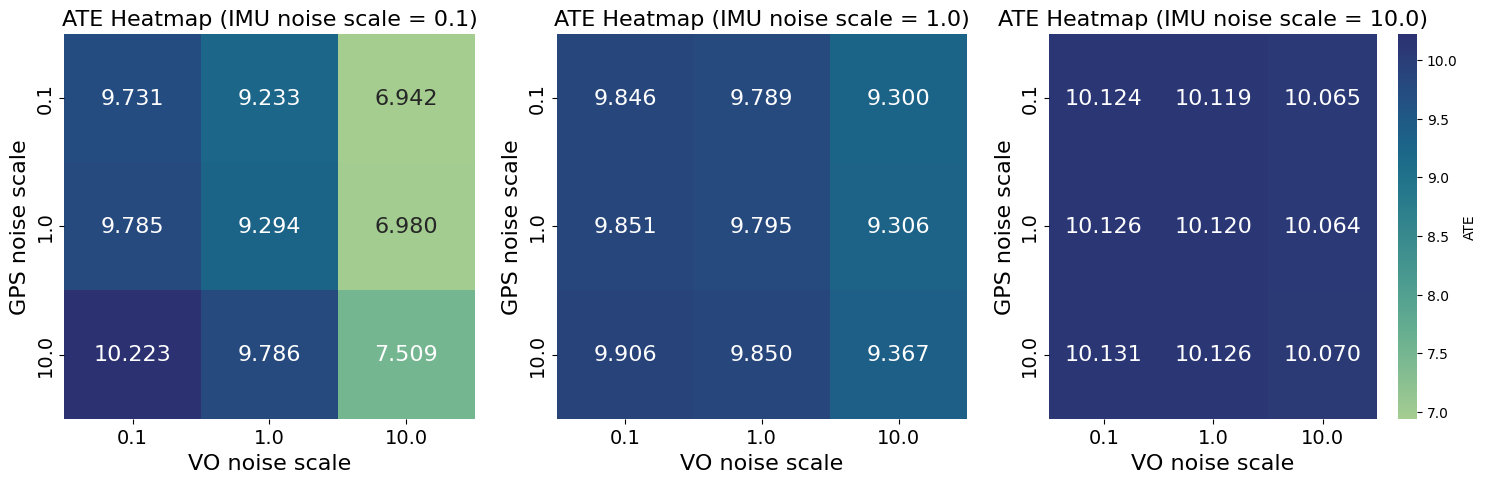

In [19]:
ate_matrix_imu_0_1 = imu_0_1_df.pivot(
    index="gps_noise_scale",
    columns="vo_noise_scale",
    values="ate"
).sort_index().sort_index(axis=1)

ate_matrix_imu_1 = imu_1_df.pivot(
    index="gps_noise_scale",
    columns="vo_noise_scale",
    values="ate"
).sort_index().sort_index(axis=1)

ate_matrix_imu_10 = imu_10_df.pivot(
    index="gps_noise_scale",
    columns="vo_noise_scale",
    values="ate"
).sort_index().sort_index(axis=1)

vmin = min(ate_matrix_imu_0_1.values.min(), ate_matrix_imu_1.values.min(), ate_matrix_imu_10.values.min())
vmax = max(ate_matrix_imu_0_1.values.max(), ate_matrix_imu_1.values.max(), ate_matrix_imu_10.values.max())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

heatmap_data = [
    (ate_matrix_imu_0_1, "ATE Heatmap (IMU noise scale = 0.1)"),
    (ate_matrix_imu_1,   "ATE Heatmap (IMU noise scale = 1.0)"),
    (ate_matrix_imu_10,  "ATE Heatmap (IMU noise scale = 10.0)"),
]

for i, (ax, (matrix, title)) in enumerate(zip(axes, heatmap_data)):
    is_last = i == len(heatmap_data) - 1
    sns.heatmap(
        matrix,
        annot=True,
        fmt=".3f",
        cmap="crest",
        vmin=vmin,
        vmax=vmax,
        ax=ax,
        cbar=is_last,
        cbar_kws={"label": "ATE"} if is_last else {}
    )
    ax.set_title(title)
    ax.set_xlabel("VO noise scale", fontsize=16)
    ax.set_ylabel("GPS noise scale", fontsize=16)
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.set_title(title, fontsize=16)
    for text in ax.texts:
        text.set_fontsize(16)

fig_filename = f'{folder_name}/ate_heatmaps.png'
fig.savefig(fig_filename, bbox_inches='tight', dpi=150)
plt.show()

In [8]:
imu_noise_scale = static_noise_df.pivot(
    index="imu_noise_scale",
    columns=["gps_noise_scale", "vo_noise_scale"],
    values="ate"
).sort_index().sort_index(axis=1)
imu_0_1_mean = imu_noise_scale.iloc[0].mean()
imu_1_mean = imu_noise_scale.iloc[1].mean()
imu_10_mean = imu_noise_scale.iloc[2].mean()
sensitivity_imu = (imu_10_mean - imu_0_1_mean) / imu_1_mean

gps_noise_scale = static_noise_df.pivot(
    index="gps_noise_scale",
    columns=["imu_noise_scale", "vo_noise_scale"],
    values="ate"
).sort_index().sort_index(axis=1)
gps_0_1_mean = gps_noise_scale.iloc[0].mean()
gps_1_mean = gps_noise_scale.iloc[1].mean()
gps_10_mean = gps_noise_scale.iloc[2].mean()
sensitivity_gps = (gps_10_mean - gps_0_1_mean) / gps_1_mean

vo_noise_scale = static_noise_df.pivot(
    index="vo_noise_scale",
    columns=["imu_noise_scale", "gps_noise_scale"],
    values="ate"
).sort_index().sort_index(axis=1)
vo_0_1_mean = vo_noise_scale.iloc[0].mean()
vo_1_mean = vo_noise_scale.iloc[1].mean()
vo_10_mean = vo_noise_scale.iloc[2].mean()
sensitivity_vo = (vo_10_mean - vo_0_1_mean) / vo_1_mean

print(f"IMU sensitivity: {sensitivity_imu:.4f}")
print(f"GPS sensitivity: {sensitivity_gps:.4f}")
print(f"VO sensitivity:  {sensitivity_vo:.4f}")

IMU sensitivity: 0.1317
GPS sensitivity: 0.0213
VO sensitivity:  -0.1149


## Analysis

The three heatmaps depict Absolute Trajectory Error for each noise scale value for GPS and Visual Odometry when IMU noise scale is set to 0.1, 1.0, and 10.0 respectively.

First of all, throughout the noise stress test, CKF has never presented filter divergence showcasing the filter's robustness on different noise environment.

The result reveals that in this multi modal fusion configuration, IMU and GPS noise scale has a crucial role such that there is a correlation between noise scale of either IMU and GPS sensor and the CKF's localization performance, espescially the selection of IMU noise scale has a significant impact on the fusion performance. The sensitivity analysis on both sensor provides positive values, which justifies the aformentioned analysis numerically.

In contrast, the scale of visual odometry noise has a negative impact on the fitler performance as it is observed that incrase in the visual odometry noise scale decreases the filter performance, as the sensitivity of VO presents negative value. This is because of the filter balancing between the GPS and VO, as positioning accuracy of GPS is much accurate than the VO, the filter relies on GPS data when VO noise scale increases resulting in aqcuiring hgih accuracy in localziation.

This experiment provides an insight on the robstness and potential of the CKF by presenting the capability of balancing between selected sensor modality based on the noise characteristic of each sensor. Moreover, it offers a possibility of integrating context-aware knowledge-based noise management localization under dynamic environment.

## Refined version

The three heatmaps illustrate the Absolute Trajectory Error (ATE) across different combinations of GPS and Visual Odometry (VO) noise scaling factors, while the IMU noise scale is fixed at 0.1, 1.0, and 10.0, respectively.

Throughout the noise stress test, the CKF did not exhibit numerical divergence or covariance instability under any of the 27 noise configurations. This indicates that the estimator remains numerically stable across substantial mis-specification of sensor noise parameters, demonstrating robustness of the overall fusion framework under varying uncertainty conditions.

The sensitivity analysis provides further quantitative insight. The computed sensitivity values are:
	•	IMU sensitivity: 0.1317
	•	GPS sensitivity: 0.0213
	•	VO sensitivity: -0.1149

The positive sensitivities for IMU and GPS indicate that increasing the assumed noise level (from 0.1 to 10) leads to an increase in trajectory error. Among the three modalities, the IMU exhibits the highest sensitivity, suggesting that the localization performance is most influenced by the assumed IMU process noise.
GPS sensitivity is comparatively small (0.0213), indicating that localization performance is relatively less sensitive to GPS noise scaling within the tested range.

In contrast, the VO sensitivity is negative (-0.1149), implying that increasing the assumed VO noise scale reduces overall trajectory error. When VO noise is increased, the filter decreases the weight assigned to VO measurements and relies more heavily on GPS updates. Since GPS provides globally referenced position information with relatively stable accuracy in the selected KITTI sequence, increasing VO noise reduces the influence of potentially drift-prone visual estimates, leading to improved overall localization accuracy.

Importantly, this does not imply that VO is detrimental; rather, it reflects dataset-dependent characteristics. In scenarios where GPS quality degrades (e.g., urban canyons or multipath conditions), the sensitivity behavior can differ. Therefore, the observed negative VO sensitivity highlights the adaptability of the filter to sensor uncertainty rather than a universal ranking of modalities.

Overall, this experiment demonstrates two key properties:
	1.	Robustness – The filter maintains stability and bounded error across large variations in assumed noise levels.
	2.	Adaptive weighting behavior – The fusion mechanism appropriately rebalances sensor contributions according to their modeled uncertainty.

From a pipeline perspective, this stress test illustrates the capability to systematically evaluate modality sensitivity and to expose how performance depends on noise modeling assumptions. Such analysis supports future integration of adaptive or context-aware noise management strategies in dynamic environments.